# Build the Political-Object Gallery

Goal: turn raw NYT images into a **labeled gallery of political-object subcategories**
(e.g. *american flag* vs *thin-blue-line flag*, *MAGA hat* vs *police cap*), parallel to
the face gallery in `data/gallery/embeddings.pkl`.

Pipeline:

1. **Segment** — Grounding-DINO detects political objects, SAM cuts each one out → padded crops
   in `data/object_crops/{category}/`. *(Reuses the model setup from
   `GroudingDINO+SAM+clustering.ipynb`; skip if crops already exist.)*
2. **Cluster** — within each category, embed crops with CLIP → UMAP → HDBSCAN.
   **`min_cluster_size` dominates the result — Stage 2b lets you sweep & tune it cheaply.**
3. **Display** — show a grid of examples per cluster, so you can eyeball and name them.
4. **Label** — fill in a `{(category, cluster) → subcategory}` map; merge it back for the record.
5. **Build** — aggregate labeled crop embeddings into `data/gallery/object_embeddings.pkl`,
   in the same `dict[label] -> list[np.ndarray]` format the face gallery uses.

Designed for **Google Colab** (GPU), but paths fall back to the local repo root.

## 0 · Setup & paths

In [ ]:
# On Colab, install the clustering/embedding deps used by Stages 2-5.
# Stage 0.5 below sets up SAM 2 + Grounding DINO (HF) for Stage 1.
# !pip install -q umap-learn hdbscan transformers supervision

In [ ]:
import os, glob, pickle, re
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd

# --- Locate the project root (Colab Drive or local repo) ---
try:
    from google.colab import drive  # noqa
    drive.mount("/content/drive", force_remount=False)
    # EDIT this to wherever POLVIFIDEL lives on your Drive:
    ROOT = Path("/content/drive/MyDrive/Coursework/dissertation/POLVIFIDEL")
    IN_COLAB = True
except ModuleNotFoundError:
    ROOT = Path(os.environ.get("POLVIFIDEL_ROOT", Path.cwd().parent))
    IN_COLAB = False

DATA_DIR         = ROOT / "data"
IMAGES_DIR       = DATA_DIR / "images"
OBJECT_CROPS_DIR = DATA_DIR / "object_crops"      # {category}/ subfolders of padded crops
CLUSTER_DIR      = DATA_DIR / "object_clusters"   # per-category cluster CSVs + embeddings
GALLERY_DIR      = DATA_DIR / "gallery"
for d in (OBJECT_CROPS_DIR, CLUSTER_DIR, GALLERY_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("ROOT      :", ROOT)
print("IN_COLAB  :", IN_COLAB)
print("images    :", IMAGES_DIR, "->", len(list(IMAGES_DIR.glob('*.jpg'))), "jpgs")

Mounted at /content/drive
ROOT      : /content/drive/MyDrive/Coursework/dissertation/POLVIFIDEL
IN_COLAB  : True
images    : /content/drive/MyDrive/Coursework/dissertation/POLVIFIDEL/data/images -> 1351 jpgs


In [ ]:
# Object list mirrors GroundingDINO+SAM+clustering.ipynb (cells 76-77), minus "building".
# Lowercased + dot-separated as the HF Grounding DINO detector expects ("queries must be
# lowercase and end with a dot"). Person/fire terms are detected but NOT clustered (they
# aren't in CLUSTER_GROUPS) plus DECOY terms (podium, microphone, table, stage) that soak up
# boxes which would otherwise be mis-grounded into banner_sign (e.g. podiums carry signage).
TEXT_PROMPT = ("man. woman. boy. girl. beard. drag. flag. banner. sign. fire. hat. helmet. "
               "podium. microphone. table. stage.")

# Detection terms grouped into categories we segment + cluster separately.
CLUSTER_GROUPS = {
    "flag":        ["flag"],
    "banner_sign": ["banner", "sign"],
    "headwear":    ["hat", "helmet"],
}
TERM2GROUP = {t: g for g, terms in CLUSTER_GROUPS.items() for t in terms}

BOX_THRESHOLD, TEXT_THRESHOLD = 0.30, 0.30   # GDINO detection thresholds
MIN_BOX_DIM, MIN_MASK_AREA    = 20, 1000
print("detect :", TEXT_PROMPT)
print("cluster:", list(CLUSTER_GROUPS))

detect : man. woman. boy. girl. beard. drag. flag. banner. sign. fire. hat. helmet. podium. microphone. table. stage.
cluster: ['flag', 'banner_sign', 'headwear']


## 0.5 · Set up SAM 2 + Grounding DINO  *(Colab GPU — run once per session)*

Follows the [Grounded-SAM-2](https://github.com/IDEA-Research/Grounded-SAM-2) recommended
recipe: **Grounding DINO is loaded via HuggingFace `transformers`**
(`IDEA-Research/grounding-dino-tiny`), not the `groundingdino` package — so there is **no repo
clone, no CUDA Deformable-Attention compilation, and no transformers version pin** (this
sidesteps the earlier `get_head_mask` / editable-install errors). SAM 2 is still built from its
repo. Same Grounding DINO model id as `scripts/02_detect_entities.py`.

**Set Runtime → GPU first.** Skip this section if `data/object_crops/` is already populated.

In [ ]:
# --- SAM 2: clone + install + checkpoint ---
import os, locale
locale.getpreferredencoding = lambda: "UTF-8"
HOME = os.getcwd()
print("HOME:", HOME)

%cd {HOME}
!git clone https://github.com/facebookresearch/segment-anything-2.git
%cd {HOME}/segment-anything-2
!pip install -q -e .
!pip install -q supervision

!mkdir -p {HOME}/checkpoints
!wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_large.pt -P {HOME}/checkpoints
%cd {HOME}

HOME: /content
/content
Cloning into 'segment-anything-2'...
remote: Enumerating objects: 1107, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 1107 (delta 10), reused 4 (delta 4), pack-reused 1093 (from 2)
Receiving objects: 100% (1107/1107), 134.85 MiB | 20.75 MiB/s, done.
Resolving deltas: 100% (385/385), done.
Updating files: 100% (569/569), done.
/content/segment-anything-2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 8.8 MB/s eta 0:00:00
  Building editable for SAM-2 (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 5.0 MB/s eta 0:00:00
   ━━━

In [ ]:
# --- SAM 2: imports + load image predictor ---
import os
import cv2
import torch
import numpy as np

# Editable install can fail to register on sys.path in Colab — add the repo dir.
import sys
if os.path.join(HOME, "segment-anything-2") not in sys.path:
    sys.path.insert(0, os.path.join(HOME, "segment-anything-2"))

from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT = f"{HOME}/checkpoints/sam2_hiera_large.pt"
CONFIG = "sam2_hiera_l.yaml"

sam2_model = build_sam2(CONFIG, CHECKPOINT, device=DEVICE, apply_postprocessing=False)
predictor = SAM2ImagePredictor(sam2_model)
print("SAM 2 loaded on", DEVICE)

SAM 2 loaded on cuda


In [ ]:
# --- Grounding DINO via HuggingFace transformers (Grounded-SAM-2 recommended path) ---
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

GDINO_MODEL_ID = "IDEA-Research/grounding-dino-tiny"
gdino_processor = AutoProcessor.from_pretrained(GDINO_MODEL_ID)
grounding_model = AutoModelForZeroShotObjectDetection.from_pretrained(GDINO_MODEL_ID).to(DEVICE).eval()
print("Grounding DINO (HF) loaded on", DEVICE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.64k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/689M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/978 [00:00<?, ?it/s]

Grounding DINO (HF) loaded on cuda


## 1 · Segment objects → padded crops  *(run-once)*

Grounding DINO (HF) detects the objects in `TEXT_PROMPT`; each matched box is handed to the
SAM 2 image predictor for a clean mask, then cropped + padded. Mirrors the Grounded-SAM-2 HF
demo (`grounded_sam2_hf_model_demo.py`): `post_process_grounded_object_detection` returns
**pixel xyxy boxes**, fed straight to `predictor.predict(box=...)`.

Crops are saved as `data/object_crops/{group}/{image_id}__box{i}.jpg` so the originating
`image_id` is recoverable. Checkpointed: re-running skips crops that already exist.

In [ ]:
# Mask -> crop helpers (ported from GroudingDINO+SAM+clustering.ipynb, cell 75).
# HF Grounding DINO returns pixel xyxy boxes directly, so the old
# convert_boxes_to_pixel_coords (normalized cxcywh -> pixel) is no longer needed.
def extract_masked_patch_fast(image, mask, box, threshold=0.5, min_area=MIN_MASK_AREA):
    x1, y1, x2, y2 = box.astype(int)
    mask_crop, image_crop = mask[y1:y2, x1:x2], image[y1:y2, x1:x2]
    binary = mask_crop > threshold
    if binary.sum() < min_area:
        return None
    ys, xs = np.nonzero(binary)
    sub_img  = image_crop[ys.min():ys.max() + 1, xs.min():xs.max() + 1]
    sub_mask = binary[ys.min():ys.max() + 1, xs.min():xs.max() + 1][:, :, None]
    return sub_img * sub_mask

def pad_to_square(img):
    h, w = img.shape[:2]
    size = max(h, w)
    padded = np.zeros((size, size, 3), dtype=img.dtype)
    yo, xo = (size - h) // 2, (size - w) // 2
    padded[yo:yo + h, xo:xo + w] = img
    return padded

In [ ]:
from tqdm import tqdm
from PIL import Image

def _detect(image):
    """Grounding DINO (HF) -> (boxes pixel-xyxy [N,4], phrase labels [N])."""
    inputs = gdino_processor(images=image, text=TEXT_PROMPT, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = grounding_model(**inputs)
    kw = dict(text_threshold=TEXT_THRESHOLD, target_sizes=[image.size[::-1]])  # (H, W)
    try:                                   # transformers >= 4.51 renamed box_threshold -> threshold
        res = gdino_processor.post_process_grounded_object_detection(
            outputs, inputs.input_ids, threshold=BOX_THRESHOLD, **kw)[0]
    except TypeError:
        res = gdino_processor.post_process_grounded_object_detection(
            outputs, inputs.input_ids, box_threshold=BOX_THRESHOLD, **kw)[0]
    labels = res.get("text_labels", res.get("labels"))   # text_labels in newer transformers
    return res["boxes"].cpu().numpy(), labels

def _to_group(label):
    lab = str(label).lower().strip()
    return TERM2GROUP.get(lab) or next((g for t, g in TERM2GROUP.items() if t in lab), None)

def segment_corpus(image_paths, overwrite=False):
    for image_path in tqdm(list(image_paths), desc="Segmenting"):
        image_id = Path(image_path).stem
        try:
            image = Image.open(image_path).convert("RGB")
        except Exception:
            continue
        image_np = np.array(image)

        boxes, labels = _detect(image)
        if len(boxes) == 0:
            continue
        groups = [_to_group(l) for l in labels]
        if not any(groups):
            continue

        predictor.set_image(image_np)
        for i, (box, group) in enumerate(zip(boxes, groups)):
            if group is None:
                continue
            x1, y1, x2, y2 = box.astype(int)
            if (x2 - x1) < MIN_BOX_DIM or (y2 - y1) < MIN_BOX_DIM:
                continue
            out_dir = OBJECT_CROPS_DIR / group
            out_dir.mkdir(parents=True, exist_ok=True)
            out_path = out_dir / f"{image_id}__box{i}.jpg"
            if out_path.exists() and not overwrite:
                continue
            masks, _, _ = predictor.predict(
                point_coords=None, point_labels=None,
                box=box[None, :], multimask_output=False)
            mask = masks[0]
            if mask.ndim > 2:
                mask = mask.squeeze(0)
            patch = extract_masked_patch_fast(image_np, mask, box)
            if patch is None:
                continue
            padded = cv2.cvtColor(pad_to_square(patch), cv2.COLOR_RGB2BGR)
            cv2.imwrite(str(out_path), padded)

# Segments ALL jpgs in data/images (~1.3k -> slow on GPU). To stay in-corpus, pass only
# df_corpus image_ids instead.
segment_corpus(IMAGES_DIR.glob("*.jpg"))

Segmenting:   0%|          | 0/1351 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:96: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)
Segmenting: 100%|██████████| 1351/1351 [26:32<00:00,  1.18s/it]


## 2 · Embed (CLIP) → reduce (UMAP) → cluster (HDBSCAN), per category

Embeddings **and** the UMAP reduction are cached per category (the slow parts), so
re-clustering with a different `min_cluster_size` in Stage 2b is near-instant.

In [ ]:
import torch
from PIL import Image
from transformers import CLIPModel, CLIPProcessor

CLIP_NAME = "laion/CLIP-ViT-L-14-DataComp.XL-s13B-b90K"
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
clip_model = CLIPModel.from_pretrained(CLIP_NAME).to(device).eval()
clip_proc  = CLIPProcessor.from_pretrained(CLIP_NAME)
print("CLIP on", device)

@torch.no_grad()
def embed_image(path):
    img = Image.open(path).convert("RGB")
    inp = clip_proc(images=img, return_tensors="pt").to(device)
    out = clip_model.get_image_features(**inp)
    if torch.is_tensor(out):
        feat = out                                   # CLIPModel: projected image embeds (1, D)
    elif getattr(out, "image_embeds", None) is not None:
        feat = out.image_embeds
    elif getattr(out, "pooler_output", None) is not None:
        feat = out.pooler_output                     # pooled vision features (1, D)
    else:
        feat = out.last_hidden_state.mean(dim=1)     # fallback: mean-pool tokens
    feat = feat / feat.norm(dim=-1, keepdim=True)    # L2-normalize
    return feat.detach().cpu().numpy().astype(np.float32).ravel()   # -> (D,)


# --- Local CLIP zero-shot relevance filter (NO API tokens) -------------------
# Removes off-category crops (e.g. podiums mis-grounded into banner_sign) using the
# CLIP model already loaded. Uses clip_model(...).logits_per_image (the proper joint
# image-text space) -- NOT embed_image (whose pooled features aren't comparable to text).
# Configure per category; categories absent here are left unfiltered.
CATEGORY_FILTERS = {
    "banner_sign": {
        "keep": ["a protest banner or sign with text", "a political poster"],
        "drop": ["a podium or lectern", "a microphone", "a person",
                 "a flag", "a building", "a table", "a stage"],
    },
}

@torch.no_grad()
def clip_keep_mask(paths, keep, drop, batch=32):
    classes, nk = keep + drop, len(keep)
    flags = []
    for i in range(0, len(paths), batch):
        imgs = [Image.open(p).convert("RGB") for p in paths[i:i + batch]]
        inp = clip_proc(text=classes, images=imgs, return_tensors="pt", padding=True).to(device)
        probs = clip_model(**inp).logits_per_image.softmax(dim=1)   # (B, n_classes)
        flags += (probs[:, :nk].sum(1) > probs[:, nk:].sum(1)).tolist()
    return flags

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.41k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

CLIP on cuda


In [ ]:
from umap import UMAP
from hdbscan import HDBSCAN

UMAP_DIMS = 5

# Per-category min_cluster_size. Start from the default; override any category in 2b.
DEFAULT_MIN_CLUSTER_SIZE = 15
MIN_CLUSTER_SIZE = {cat: DEFAULT_MIN_CLUSTER_SIZE for cat in CLUSTER_GROUPS}

# Cache: category -> {"paths", "embs" (N,512), "reduced" (N,UMAP_DIMS)}
EMB_STORE = {}

# Cache of CLIP-filter results so re-clustering during tuning doesn't re-run CLIP.
_FILTER_CACHE = {}

def _filtered_paths(category, paths):
    """Drop off-category crops via the local CLIP filter (cached). No API tokens."""
    if category not in CATEGORY_FILTERS:
        return paths, list(range(len(paths)))
    if category not in _FILTER_CACHE:
        mask = clip_keep_mask(paths, **CATEGORY_FILTERS[category])
        _FILTER_CACHE[category] = set(p for p, k in zip(paths, mask) if k)
        kept = len(_FILTER_CACHE[category])
        print(f"[{category}] CLIP filter: kept {kept}/{len(paths)} "
              f"(dropped {len(paths) - kept} off-category crops, e.g. podiums)")
    keep_set = _FILTER_CACHE[category]
    idx = [i for i, pth in enumerate(paths) if pth in keep_set]
    return [paths[i] for i in idx], idx

def _ensure_reduced(category, recompute=False):
    '''Embed crops + UMAP-reduce, caching to disk and EMB_STORE. The slow step.'''
    if not recompute and category in EMB_STORE:
        c = EMB_STORE[category]
        return c["paths"], c["embs"], c["reduced"]

    npz = CLUSTER_DIR / f"{category}_emb.npz"
    if not recompute and npz.exists():
        d = np.load(npz, allow_pickle=True)
        paths, embs, reduced = list(d["paths"]), d["embeddings"], d["reduced"]
        embs = np.asarray(embs).reshape(len(paths), -1)   # ensure 2-D (cache safety)
    else:
        crop_dir = OBJECT_CROPS_DIR / category
        paths = sorted(glob.glob(str(crop_dir / "*.jpg")) + glob.glob(str(crop_dir / "*.png")))
        if not paths:
            return [], None, None
        embs = np.vstack([embed_image(p) for p in tqdm(paths, desc=f"embed {category}")])
        embs = embs.reshape(embs.shape[0], -1)   # ensure 2-D (N, D) for UMAP/HDBSCAN
        reduced = UMAP(n_components=UMAP_DIMS, random_state=42).fit_transform(embs)
        np.savez_compressed(npz, paths=np.array(paths), embeddings=embs, reduced=reduced)

    EMB_STORE[category] = {"paths": paths, "embs": embs, "reduced": reduced}
    return paths, embs, reduced

def cluster_category(category, min_cluster_size=None):
    '''(Re)cluster a category from CACHED reduced embeddings — cheap to repeat.'''
    mcs = min_cluster_size or MIN_CLUSTER_SIZE.get(category, DEFAULT_MIN_CLUSTER_SIZE)
    paths, embs, reduced = _ensure_reduced(category)
    if not paths:
        print(f"[{category}] no crops — skipping"); return None
    paths, keep_idx = _filtered_paths(category, paths)   # drop off-category crops (no tokens)
    reduced = reduced[keep_idx]
    if len(paths) < mcs:
        print(f"[{category}] {len(paths)} crops < min_cluster_size={mcs} — skipping")
        return None
    labels = HDBSCAN(min_cluster_size=mcs, min_samples=1).fit_predict(reduced)
    df = pd.DataFrame({
        "crop_path": paths,
        "image_id":  [Path(p).stem.split("__box")[0] for p in paths],
        "category":  category,
        "cluster":   labels,
    })
    n_clusters = len(set(labels) - {-1})
    print(f"[{category}] mcs={mcs}: {len(paths)} crops → {n_clusters} clusters "
          f"(+{(labels == -1).sum()} noise)")
    return df

cluster_dfs = {}
for category in CLUSTER_GROUPS:
    out = cluster_category(category)
    if out is not None:
        cluster_dfs[category] = out

[flag] mcs=15: 657 crops → 12 clusters (+89 noise)
[banner_sign] CLIP filter: kept 930/1467 (dropped 537 off-category crops, e.g. podiums)
[banner_sign] mcs=15: 930 crops → 25 clusters (+261 noise)
[headwear] mcs=15: 549 crops → 2 clusters (+14 noise)


[banner_sign] CLIP filter dropped 537/1467 crops


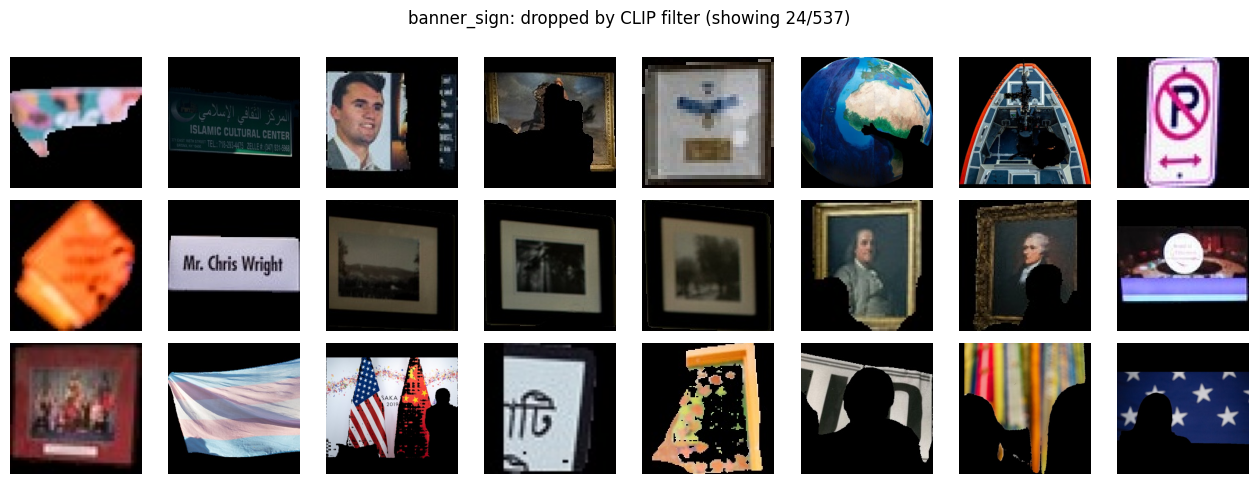

In [ ]:
# --- Sanity-check the CLIP filter: show the crops it DROPPED from a category ---
# Self-contained (imports its own matplotlib). Adjust CATEGORY_FILTERS wording if it
# over/under-drops. Re-clustering uses the cached mask, so this just visualizes it.
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show_filtered_out(category="banner_sign", n=24, cols=8):
    paths, _, _ = _ensure_reduced(category)
    kept, _ = _filtered_paths(category, paths)          # populates/uses _FILTER_CACHE
    keep_set = set(kept)
    dropped = [p for p in paths if p not in keep_set]
    print(f"[{category}] CLIP filter dropped {len(dropped)}/{len(paths)} crops")
    if not dropped:
        print("  (nothing dropped — no filter configured, or all kept)"); return
    sample = dropped[:n]
    rows = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.6), squeeze=False)
    for ax in axes.ravel():
        ax.axis("off")
    for ax, pth in zip(axes.ravel(), sample):
        try: ax.imshow(mpimg.imread(pth))
        except Exception: pass
    plt.suptitle(f"{category}: dropped by CLIP filter (showing {len(sample)}/{len(dropped)})", y=1.0)
    plt.tight_layout(); plt.show()

show_filtered_out("banner_sign")

## 2b · Tune `min_cluster_size` per object  ← *the knob that dominates everything*

`min_cluster_size` controls granularity: small values fragment an object into many tiny
clusters; large values merge distinct subcategories and push more crops into noise (`-1`).
The right value differs per umbrella object, so tune **one category at a time**:

1. `sweep_min_cluster_size("flag")` — counts / noise across candidate values (fast table).
2. `preview("flag", 20)` — actually **see the example crops** for each cluster at that value.
   Re-run with different values until the groupings look right.
3. Commit the chosen value per category, then rebuild all clusterings.

Everything reuses the cached UMAP reduction, so each preview is near-instant.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def display_clusters(df, samples_per_cluster=8, max_clusters=None):
    """Grid of example crops, one row per cluster. Each row is headed with the exact
    LABELS key (category, cluster_id) so you can copy it into Stage 4. -1 = noise."""
    cat = df["category"].iloc[0]
    clusters = defaultdict(list)
    for _, r in df.iterrows():
        clusters[r["cluster"]].append(r["crop_path"])
    keys = sorted(clusters, key=lambda k: (k == -1, -len(clusters[k])))[:max_clusters]
    fig, axes = plt.subplots(len(keys), samples_per_cluster,
                             figsize=(samples_per_cluster * 1.7, len(keys) * 1.9),
                             squeeze=False)
    for i, k in enumerate(keys):
        sample = clusters[k][:samples_per_cluster]
        for j in range(samples_per_cluster):
            ax = axes[i][j]; ax.axis("off")
            if j < len(sample):
                try: ax.imshow(mpimg.imread(sample[j]))
                except Exception: pass
        key = "noise (-1)" if k == -1 else f"({cat!r}, {k})"
        axes[i][0].set_title(f"{key}   n={len(clusters[k])}",
                             loc="left", fontsize=11, fontweight="bold")
    mcs = df["min_cluster_size"].iloc[0] if "min_cluster_size" in df else "?"
    plt.suptitle(f'{cat}  (min_cluster_size={mcs})', y=1.0, fontsize=14)
    plt.tight_layout(); plt.show()

def sweep_min_cluster_size(category, values=(5, 8, 10, 15, 20, 30, 50)):
    """Print cluster-count / noise / sizes across candidate min_cluster_size values."""
    paths, embs, reduced = _ensure_reduced(category)
    if not paths:
        print(f"[{category}] no crops"); return
    print(f"[{category}]  {len(paths)} crops")
    print(f"  {'mcs':>4} | {'clusters':>8} | {'noise':>6} | sizes (largest first)")
    print("  " + "-" * 60)
    for m in values:
        if len(paths) < m:
            continue
        labels = HDBSCAN(min_cluster_size=m, min_samples=1).fit_predict(reduced)
        sizes = sorted((c for k, c in Counter(labels).items() if k != -1), reverse=True)
        print(f"  {m:>4} | {len(sizes):>8} | {(labels == -1).mean():>5.0%} | {sizes[:10]}")

def preview(category, min_cluster_size):
    """Cluster ONE category at a trial min_cluster_size and SHOW the example grids.
    Does NOT commit -- just for eyeballing. Cheap (reuses the cached UMAP reduction)."""
    df = cluster_category(category, min_cluster_size)
    if df is not None:
        df = df.copy()
        df["min_cluster_size"] = min_cluster_size
        display_clusters(df)
    return df

In [ ]:
# Tune ONE umbrella object at a time. Edit the category + value and re-run this cell freely.
#   1) sweep to see counts;  2) preview to SEE the example crops for each cluster.
sweep_min_cluster_size("flag")
preview("flag", 8)        # try others: preview("flag", 10), preview("flag", 30), ...

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
preview("flag", 5)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
preview("banner_sign", 5)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
preview("headwear", 10)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# When the grids look right, set the chosen value PER category, then rebuild all clusterings.
MIN_CLUSTER_SIZE.update({
    "flag":        5,   # <- set each from your previews
    "banner_sign": 5,
    "headwear":    10,
})
cluster_dfs = {c: cluster_category(c) for c in CLUSTER_GROUPS}
cluster_dfs = {k: v for k, v in cluster_dfs.items() if v is not None}
print("committed:", {c: MIN_CLUSTER_SIZE[c] for c in cluster_dfs})

[flag] mcs=5: 657 crops → 39 clusters (+72 noise)
[banner_sign] mcs=5: 930 crops → 76 clusters (+213 noise)
[headwear] mcs=10: 549 crops → 19 clusters (+90 noise)
committed: {'flag': 5, 'banner_sign': 5, 'headwear': 10}


## 2c · VLM-assisted re-cluster + naming  *(best for banners / signs)*

Banners/signs are defined by their **text**, which CLIP's visual clustering misses — hence the
diversity headache. Here a VLM (1) transcribes each crop's slogan + theme, (2) we re-cluster on
that **text** (sentence embeddings) so groups share a message, and (3) the VLM proposes a
`snake_case` label per cluster, which you review before adopting.

Calls the Sandbox via the **Portkey gateway** (`AI_SANDBOX_KEY`); defaults to **gpt-4o-mini**,
override with env `VLM_MODEL` (e.g. `gemini-3.1-pro-preview` or `claude-opus-4-7` for stronger OCR). Per-crop transcription is cached to `data/object_clusters/{category}_vlm.csv`
(resumable). Tune the text `min_cluster_size` by re-running `recluster_on_text(cat, N)` — it
reuses the cached text reduction.

Note: Stage 5 still stores each crop's **visual** CLIP embedding as the gallery reference, so a
text-defined subcategory may be visually diverse — fine for labeling, but detection-time matching
of banners is better done by text/OCR too (a later step).

In [ ]:
!pip install -q openai portkey-ai sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.7 MB/s eta 0:00:00


In [ ]:
# VLM via Princeton AI Sandbox (Portkey AI Gateway).  On Colab first run:
#   !pip install -q portkey-ai sentence-transformers
# Set your key first (do NOT hardcode):  os.environ["AI_SANDBOX_KEY"] = "<key>"   (or export it)
import os, io, re, json, base64
from PIL import Image
from portkey_ai import Portkey

# Key: Colab secret (Secrets panel) first, then the AI_SANDBOX_KEY env var.
AI_SANDBOX_KEY = os.getenv("AI_SANDBOX_KEY")
if not AI_SANDBOX_KEY:
    try:
        from google.colab import userdata
        AI_SANDBOX_KEY = userdata.get("AI_SANDBOX_KEY")
    except Exception:
        pass
if not AI_SANDBOX_KEY:
    raise ValueError("Set AI_SANDBOX_KEY: add it to Colab Secrets (key icon) "
                     "or export AI_SANDBOX_KEY before running.")
vlm = Portkey(api_key=AI_SANDBOX_KEY)

# Image-capable Sandbox models: gpt-5-mini, gpt-4o-mini, gemini-3.1-pro-preview,
# claude-opus-4-7, claude-sonnet-4-6, claude-haiku-4-5, Llama-4-Scout-17B-16E-Instruct,
# mistral-small-2503, mistral-medium-2505.  Override via env VLM_MODEL.
VLM_MODEL = os.environ.get("VLM_MODEL", "gpt-4o-mini")   # fast + stable for a per-crop loop
print("VLM (Portkey) ready | model:", VLM_MODEL)

SYSTEM_MSG = "You are a helpful assistant that analyzes images of political objects."

def _b64_small(path, size=384):
    img = Image.open(path).convert("RGB"); img.thumbnail((size, size))
    buf = io.BytesIO(); img.save(buf, "JPEG", quality=90)
    return f"data:image/jpeg;base64,{base64.b64encode(buf.getvalue()).decode()}"

def _extract_json(s):
    m = re.search(r"\{.*\}", s.strip(), re.S)
    return m.group(0) if m else "{}"

def _vlm_json(content, model=None, max_tokens=160):
    # No temperature arg -> avoids gpt-5 reasoning-model restrictions; Portkey mirrors OpenAI.
    r = vlm.chat.completions.create(
        model=model or VLM_MODEL,
        messages=[{"role": "system", "content": SYSTEM_MSG},
                  {"role": "user", "content": content}],
        max_tokens=max_tokens)
    return json.loads(_extract_json(r.choices[0].message.content))

VLM (Portkey) ready | model: gpt-4o-mini


In [ ]:
# (a) connectivity — 1 tiny call
r = vlm.chat.completions.create(model=VLM_MODEL,
        messages=[{"role":"user","content":"Say OK"}], max_tokens=5)
print("connectivity:", r.choices[0].message.content)


DESCRIBE_PROMPT = (
    "This is a cropped banner / sign / poster from a U.S. political news photo. "
    "Transcribe any visible text VERBATIM and give a short political theme. "
    'Reply ONLY as JSON: {"text": "<verbatim text or empty>", "theme": "<cause / affiliation / message>"}.'
)

# (b) one real crop through the full describe path — 1 call, checks image payload + JSON parse
import glob
p = sorted(glob.glob(str(OBJECT_CROPS_DIR / "banner_sign" / "*.jpg")))[0]
print(p, "->", _vlm_json(
    [{"type":"text","text":DESCRIBE_PROMPT},
     {"type":"image_url","image_url":{"url":_b64_small(p)}}]))


connectivity: OK!
/content/drive/MyDrive/Coursework/dissertation/POLVIFIDEL/data/object_crops/banner_sign/00DC-TRUMP-SOUTH-AFRICA-TOP-pfcw__box12.jpg -> {'text': 'We need Financial and Security Support NOT Asylum', 'theme': 'immigration policy and national security'}


In [ ]:
import time
import pandas as pd
from tqdm import tqdm

DESCRIBE_PROMPT = (
    "This is a cropped banner / sign / poster from a U.S. political news photo. "
    "Transcribe any visible text VERBATIM and give a short political theme. "
    'Reply ONLY as JSON: {"text": "<verbatim text or empty>", "theme": "<cause / affiliation / message>"}.'
)

CHECKPOINT_EVERY = 20   # write the CSV every N crops (not every crop -> avoids slow Drive I/O)

def _describe_one(pth, model=None, retries=4):
    """One crop -> (text, theme, status). Retries transient API errors with backoff."""
    content = [{"type": "text", "text": DESCRIBE_PROMPT},
               {"type": "image_url", "image_url": {"url": _b64_small(pth)}}]
    for attempt in range(retries):
        try:
            obj = _vlm_json(content, model)
            return obj.get("text", ""), obj.get("theme", ""), "ok"
        except Exception:
            if attempt == retries - 1:
                return "", "", "error"
            time.sleep(2 ** attempt)   # 1s, 2s, 4s backoff

def describe_crops(category, model=None, overwrite=False):
    # VLM transcribes each crop -> data/object_clusters/{category}_vlm.csv (resumable).
    out_csv = CLUSTER_DIR / f"{category}_vlm.csv"
    # Filtered/clustered crop list so we never spend tokens on off-category crops.
    if category in cluster_dfs:
        paths = cluster_dfs[category]["crop_path"].tolist()
    else:
        _all, _, _ = _ensure_reduced(category)
        paths, _ = _filtered_paths(category, _all)

    # Resume: only treat previously SUCCESSFUL rows as done, so errored crops get retried.
    done = {}
    if out_csv.exists() and not overwrite:
        prev = pd.read_csv(out_csv).fillna("")
        if "status" not in prev:                       # older CSVs: a row with a theme = ok
            prev["status"] = prev["theme"].map(lambda x: "ok" if str(x).strip() else "error")
        for r in prev.itertuples():
            if r.status == "ok":
                done[r.crop_path] = (r.text, r.theme)

    rows, since_save, n_new, n_err = [], 0, 0, 0
    for pth in tqdm(paths, desc=f"VLM describe {category}"):
        if pth in done:
            t, th, st = (*done[pth], "ok")
        else:
            t, th, st = _describe_one(pth, model)
            n_new += 1; n_err += (st == "error"); since_save += 1
        rows.append({"crop_path": pth, "text": t, "theme": th, "status": st})
        if since_save >= CHECKPOINT_EVERY:
            pd.DataFrame(rows).to_csv(out_csv, index=False); since_save = 0
    pd.DataFrame(rows).to_csv(out_csv, index=False)      # final checkpoint
    df = pd.DataFrame(rows)
    print(f"described {len(df)} {category} crops ({n_new} new, {n_err} errors) -> {out_csv}")
    if n_err:
        print(f"  {n_err} crops errored (not cached as done) -- just re-run to retry them.")
    return df

vlm_desc = describe_crops("banner_sign")
vlm_desc.head(12)

VLM describe banner_sign: 100%|██████████| 930/930 [00:40<00:00, 22.71it/s]

described 930 banner_sign crops (37 new, 0 errors) -> /content/drive/MyDrive/Coursework/dissertation/POLVIFIDEL/data/object_clusters/banner_sign_vlm.csv


,crop_path,text,theme,status
0,/content/drive/MyDrive/Coursework/dissertation...,We need\nFinancial and\nSecurity Support\nNOT ...,immigration policy/financial support,ok
1,/content/drive/MyDrive/Coursework/dissertation...,INVESTIGATE\nGovernment\ninvolvement in\nALL F...,Call for investigation into government involve...,ok
2,/content/drive/MyDrive/Coursework/dissertation...,Hands off our children,Protecting Children from Political Influence,ok
3,/content/drive/MyDrive/Coursework/dissertation...,STOP\nApartheid 2.0,Opposition to systemic inequality or discrimin...,ok
4,/content/drive/MyDrive/Coursework/dissertation...,Billionaire PAY YOUR SHARE,Taxation / Economic Equality,ok
5,/content/drive/MyDrive/Coursework/dissertation...,TAX RELIEF FØR THE NEEDY NØT THE GREEDY,Income equality and social justice,ok
6,/content/drive/MyDrive/Coursework/dissertation...,REAL Men PAY TAXES,Taxation and masculinity,ok
7,/content/drive/MyDrive/Coursework/dissertation...,TRUMP PENCE,Republican Party / Support for Trump-Pence ticket,ok
8,/content/drive/MyDrive/Coursework/dissertation...,DON'T HATE IN NEIGHBOR,Anti-hate message,ok
9,/content/drive/MyDrive/Coursework/dissertation...,Death has no sting and life has no end. We are...,Support and faith in the face of loss,ok


In [ ]:
# pip install -q sentence-transformers  (if needed)
from sentence_transformers import SentenceTransformer

_txt_model = SentenceTransformer("all-MiniLM-L6-v2",
                                 device=("cuda" if torch.cuda.is_available() else "cpu"))

def text_reduce(category, vlm_df, recompute=False):
    # Embed "theme. text" with a sentence encoder, UMAP-reduce, cache in EMB_STORE[cat+"_text"].
    key = category + "_text"
    if not recompute and key in EMB_STORE:
        c = EMB_STORE[key]; return c["paths"], c["reduced"], c["meta"]
    texts = (vlm_df["theme"].fillna("") + ". " + vlm_df["text"].fillna("")).tolist()
    temb = _txt_model.encode(texts, normalize_embeddings=True, show_progress_bar=True)
    reduced = UMAP(n_components=UMAP_DIMS, random_state=42).fit_transform(temb)
    EMB_STORE[key] = {"paths": list(vlm_df["crop_path"]), "reduced": reduced,
                      "meta": vlm_df.reset_index(drop=True)}
    return list(vlm_df["crop_path"]), reduced, vlm_df.reset_index(drop=True)

def recluster_on_text(category, min_cluster_size=8):
    # Cheap to repeat: reuses the cached text reduction. Returns a cluster_df with VLM fields.
    st = EMB_STORE[category + "_text"]
    labels = HDBSCAN(min_cluster_size=min_cluster_size, min_samples=1).fit_predict(st["reduced"])
    meta = st["meta"]
    df = pd.DataFrame({
        "crop_path": st["paths"],
        "image_id":  [Path(p).stem.split("__box")[0] for p in st["paths"]],
        "category":  category,
        "cluster":   labels,
        "vlm_text":  meta["text"].values,
        "vlm_theme": meta["theme"].values,
        "min_cluster_size": min_cluster_size,
    })
    print(f"[{category}] TEXT re-cluster mcs={min_cluster_size}: "
          f"{len(set(labels) - {-1})} clusters (+{(labels == -1).sum()} noise)")
    return df

# Build the text reduction once, then tune mcs cheaply (same idea as Stage 2b).
text_reduce("banner_sign", vlm_desc)
banner_df = recluster_on_text("banner_sign", min_cluster_size=8)
display_clusters(banner_df)     # clusters now grouped by slogan/theme, not visual appearance

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
NAME_PROMPT = (
    "Below are transcribed texts/themes of {category} crops placed in ONE cluster. "
    "Give a short snake_case subcategory label for their shared political message or affiliation "
    "(e.g. blm_banner, pro_palestine_sign, maga_sign, union_banner). "
    'Reply ONLY as JSON: {{"label": "<snake_case>", "coherent": true/false}}.\n\nItems:\n{items}'
)

def name_clusters(category, df, model=None, max_items=15):
    sugg = {}
    for k in sorted(set(df["cluster"]) - {-1}):
        sub = df[df["cluster"] == k]
        items = "\n".join(f"- {t} | {th}" for t, th in
                           zip(sub["vlm_text"].head(max_items), sub["vlm_theme"].head(max_items)))
        try:
            obj = _vlm_json([{"type": "text",
                              "text": NAME_PROMPT.format(category=category, items=items)}],
                            model, max_tokens=40)
        except Exception:
            obj = {"label": "", "coherent": False}
        sugg[(category, int(k))] = obj
        print(f"  cl {k:>2} (n={len(sub):>3}): {obj.get('label','')!r}  "
              f"[{'ok' if obj.get('coherent') else 'MIXED'}]")
    return sugg

name_suggestions = name_clusters("banner_sign", banner_df)

  cl  0 (n= 36): 'unknown_political_message'  [MIXED]
  cl  1 (n=  9): 'unclear_political_message'  [MIXED]
  cl  2 (n= 23): 'immigrant_rights_banner'  [ok]
  cl  3 (n=  8): 'tps_support'  [ok]
  cl  4 (n= 19): 'immigrant_rights_banner'  [ok]
  cl  5 (n= 20): 'rent_control_advocacy'  [ok]
  cl  6 (n=  9): 'immigration_rights_banner'  [ok]
  cl  7 (n= 13): 'bring_kilmar_home'  [ok]
  cl  8 (n= 20): 'anti_ice_signs'  [ok]
  cl  9 (n= 44): 'labor_rights'  [ok]
  cl 10 (n= 10): 'immigration_rights'  [ok]
  cl 11 (n= 22): 'immigration_reform'  [ok]
  cl 12 (n=  9): 'support_for_workers'  [ok]
  cl 13 (n= 15): 'civil_service_advocacy'  [ok]
  cl 14 (n=  8): 'maga_sign'  [ok]
  cl 15 (n=  9): 'national_security'  [ok]
  cl 16 (n= 12): 'economic_policy'  [ok]
  cl 17 (n= 16): 'faith_and_inclusivity'  [ok]
  cl 18 (n= 12): 'remembrance_and_celebration'  [ok]
  cl 19 (n= 16): 'foreign_aid_support'  [ok]
  cl 20 (n= 14): 'lgbtq_rights'  [ok]
  cl 21 (n= 29): 'womens_rights_healthcare'  [ok]
  cl 

In [ ]:
# Adopt the text-based clustering for banner_sign downstream (Stage 4b / Stage 5 read cluster_dfs).
cluster_dfs["banner_sign"] = banner_df

# Pre-filled LABELS lines from the VLM -- REVIEW (especially [MIXED]), then paste into Stage 4.
print("# --- VLM-suggested labels for banner_sign (review before using) ---")
for (cat, k), s in sorted(name_suggestions.items()):
    flag = "" if s.get("coherent") else "   # MIXED - verify"
    print(f'    ({cat!r}, {k}): "{s.get("label","")}",{flag}')

# --- VLM-suggested labels for banner_sign (review before using) ---
    ('banner_sign', 0): "unknown_political_message",   # MIXED - verify
    ('banner_sign', 1): "unclear_political_message",   # MIXED - verify
    ('banner_sign', 2): "immigrant_rights_banner",
    ('banner_sign', 3): "tps_support",
    ('banner_sign', 4): "immigrant_rights_banner",
    ('banner_sign', 5): "rent_control_advocacy",
    ('banner_sign', 6): "immigration_rights_banner",
    ('banner_sign', 7): "bring_kilmar_home",
    ('banner_sign', 8): "anti_ice_signs",
    ('banner_sign', 9): "labor_rights",
    ('banner_sign', 10): "immigration_rights",
    ('banner_sign', 11): "immigration_reform",
    ('banner_sign', 12): "support_for_workers",
    ('banner_sign', 13): "civil_service_advocacy",
    ('banner_sign', 14): "maga_sign",
    ('banner_sign', 15): "national_security",
    ('banner_sign', 16): "economic_policy",
    ('banner_sign', 17): "faith_and_inclusivity",
    ('banner_sign', 18): "remembrance_and_cele

## 3 · Display all categories at once  *(optional)*

Per-category tuning lives in **2b** (`preview`). This cell just re-displays every committed
category together. `-1` rows are HDBSCAN noise. Note each cluster's id + count — you'll use the
ids in Stage 4.

In [37]:
# Display ALL clusters for every committed category (max_clusters=None = no cap).
for category, df in cluster_dfs.items():
    n = len(set(df["cluster"]) - {-1})
    print(f"{category}: {n} clusters (+ noise)")
    display_clusters(df, max_clusters=None)

Output hidden; open in https://colab.research.google.com to view.

## 4 · Record your labels

Run the next cell to print an editable template, then fill in a subcategory name for
each `(category, cluster)`. Leave a cluster out (or set it to `""`) to drop it — do this
for noise / junk clusters. Multiple clusters can share a label (they'll be merged).

In [ ]:
# Auto-generate a template from the clusters you found (noise excluded).
print("LABELS = {")
for category, df in cluster_dfs.items():
    for k in sorted(set(df["cluster"]) - {-1}):
        n = (df["cluster"] == k).sum()
        print(f'    ({category!r}, {int(k)}): "",   # n={n}')
print("}")

LABELS = {
    ('flag', 0): "",   # n=6
    ('flag', 1): "",   # n=5
    ('flag', 2): "",   # n=7
    ('flag', 3): "",   # n=32
    ('flag', 4): "",   # n=6
    ('flag', 5): "",   # n=11
    ('flag', 6): "",   # n=11
    ('flag', 7): "",   # n=8
    ('flag', 8): "",   # n=28
    ('flag', 9): "",   # n=5
    ('flag', 10): "",   # n=11
    ('flag', 11): "",   # n=18
    ('flag', 12): "",   # n=8
    ('flag', 13): "",   # n=7
    ('flag', 14): "",   # n=8
    ('flag', 15): "",   # n=12
    ('flag', 16): "",   # n=16
    ('flag', 17): "",   # n=20
    ('flag', 18): "",   # n=16
    ('flag', 19): "",   # n=19
    ('flag', 20): "",   # n=16
    ('flag', 21): "",   # n=18
    ('flag', 22): "",   # n=103
    ('flag', 23): "",   # n=10
    ('flag', 24): "",   # n=6
    ('flag', 25): "",   # n=24
    ('flag', 26): "",   # n=5
    ('flag', 27): "",   # n=12
    ('flag', 28): "",   # n=23
    ('flag', 29): "",   # n=6
    ('flag', 30): "",   # n=9
    ('flag', 31): "",   # n=5
    ('flag', 32): ""

In [38]:
# Paste the printed template here and fill in names, e.g.:
LABELS = {
    ('flag', 0): "unknown",   # n=6
    ('flag', 1): "harvard",   # n=5
    ('flag', 2): "unknown",   # n=7
    ('flag', 3): "unknown",   # n=32
    ('flag', 4): "mexico",   # n=6
    ('flag', 5): "iran",   # n=11
    ('flag', 6): "unknown",   # n=11
    ('flag', 7): "unknown",   # n=8
    ('flag', 8): "palestine",   # n=28
    ('flag', 9): "american",   # n=5
    ('flag', 10): "american",   # n=11
    ('flag', 11): "american",   # n=18
    ('flag', 12): "american",   # n=8
    ('flag', 13): "american",   # n=7
    ('flag', 14): "american",   # n=8
    ('flag', 15): "unknown",   # n=12
    ('flag', 16): "american",   # n=16
    ('flag', 17): "american",   # n=20
    ('flag', 18): "us gov",   # n=16
    ('flag', 19): "american",   # n=19
    ('flag', 20): "american",   # n=16
    ('flag', 21): "american",   # n=18
    ('flag', 22): "american",   # n=103
    ('flag', 23): "unknown",   # n=10
    ('flag', 24): "unknown",   # n=6
    ('flag', 25): "unknown",   # n=24
    ('flag', 26): "europe",   # n=5
    ('flag', 27): "unknown",   # n=12
    ('flag', 28): "unknown",   # n=23
    ('flag', 29): "unknown",   # n=6
    ('flag', 30): "unknown",   # n=9
    ('flag', 31): "american",   # n=5
    ('flag', 32): "american",   # n=15
    ('flag', 33): "unknown",   # n=9
    ('flag', 34): "american",   # n=10
    ('flag', 35): "unknown",   # n=10
    ('flag', 36): "unknown",   # n=20
    ('flag', 37): "american",   # n=15
    ('flag', 38): "american",   # n=15
    ('banner_sign', 0): "unknown",   # MIXED - verify
    ('banner_sign', 1): "unknown",   # MIXED - verify
    ('banner_sign', 2): "immigrant_rights_banner",
    ('banner_sign', 3): "tps_support",
    ('banner_sign', 4): "immigrant_rights_banner",
    ('banner_sign', 5): "rent_control_advocacy",
    ('banner_sign', 6): "immigration_rights_banner",
    ('banner_sign', 7): "bring_kilmar_home",
    ('banner_sign', 8): "anti_ice_signs",
    ('banner_sign', 9): "labor_rights",
    ('banner_sign', 10): "immigration_rights",
    ('banner_sign', 11): "immigration_reform",
    ('banner_sign', 12): "unknown",
    ('banner_sign', 13): "civil_service_advocacy",
    ('banner_sign', 14): "maga_sign",
    ('banner_sign', 15): "national_security",
    ('banner_sign', 16): "unknown",
    ('banner_sign', 17): "unknown",
    ('banner_sign', 18): "unknown",
    ('banner_sign', 19): "foreign_aid_support",
    ('banner_sign', 20): "lgbtq_rights",
    ('banner_sign', 21): "womens_rights_healthcare",
    ('banner_sign', 22): "human_rights_banner",
    ('banner_sign', 23): "unknown",
    ('banner_sign', 24): "education_and_child_welfare",
    ('banner_sign', 25): "release_mahmoud_khalil",
    ('banner_sign', 26): "anti_musk",
    ('banner_sign', 27): "unknown",
    ('banner_sign', 28): "community_empowerment",
    ('banner_sign', 29): "cultural_and_language_identity",
    ('banner_sign', 30): "political_satires",
    ('banner_sign', 31): "epstein_accountability",
    ('banner_sign', 32): "free_speech_advocacy",
    ('banner_sign', 33): "social_justice_advocacy",
    ('banner_sign', 34): "voting_rights_advocacy",
    ('banner_sign', 35): "unknown",
    ('banner_sign', 36): "unknown",
    ('banner_sign', 37): "criminal_justice",
    ('banner_sign', 38): "anti_trump_movement",
    ('banner_sign', 39): "anti_military_intervention",
    ('banner_sign', 40): "pro_palestine_sign",
    ('banner_sign', 41): "unknown",
    ('banner_sign', 42): "unknown",
    ('banner_sign', 43): "unknown",
    ('banner_sign', 44): "democratic_election_signs",
    ('banner_sign', 45): "trump_support",
    ('banner_sign', 46): "unknown",
    ('headwear', 0): "Palestinian Keffiyeh scarf",   # n=14
    ('headwear', 1): "police hat",   # n=27
    ('headwear', 2): "cowboy",   # n=24
    ('headwear', 3): "maga",   # n=13
    ('headwear', 4): "maga",   # n=15
    ('headwear', 5): "helmet",   # n=68
    ('headwear', 6): "unknown",   # n=32
    ('headwear', 7): "unknown",   # n=14
    ('headwear', 8): "unknown",   # n=77
    ('headwear', 9): "unknown",   # n=12
    ('headwear', 10): "unknown",   # n=26
    ('headwear', 11): "unknown",   # n=11
    ('headwear', 12): "unknown",   # n=14
    ('headwear', 13): "police hat",   # n=19
    ('headwear', 14): "unknown",   # n=29
    ('headwear', 15): "beret",   # n=11
    ('headwear', 16): "unknown",   # n=16
    ('headwear', 17): "unknown",   # n=12
    ('headwear', 18): "unknown",   # n=25
}
assert LABELS, "Fill in LABELS above before running."

## 4b · Merge labels back into the cluster records  *(reproducibility)*

Writes a `subcategory` column into each `data/object_clusters/{category}_clusters.csv`
and a combined `data/object_clusters/object_labels.csv` — a permanent, auditable record
of which crop got which label under which `min_cluster_size`. Re-runnable: re-running with
an edited `LABELS` (or new `min_cluster_size`) just overwrites the record.

In [39]:
def apply_labels(LABELS, mcs_used=None):
    mcs_used = mcs_used or MIN_CLUSTER_SIZE
    frames = []
    for category, df in cluster_dfs.items():
        df = df.copy()
        df["subcategory"]     = df["cluster"].map(lambda k: LABELS.get((category, int(k)), ""))
        df["min_cluster_size"] = mcs_used.get(category, DEFAULT_MIN_CLUSTER_SIZE)
        df.to_csv(CLUSTER_DIR / f"{category}_clusters.csv", index=False)
        frames.append(df)

    alldf = pd.concat(frames, ignore_index=True)
    alldf.to_csv(CLUSTER_DIR / "object_labels.csv", index=False)

    labeled = alldf[alldf["subcategory"] != ""]
    print(f"{len(labeled)}/{len(alldf)} crops labeled "
          f"across {labeled['subcategory'].nunique()} subcategories.")
    print("\nCrops per subcategory:")
    for name, n in labeled["subcategory"].value_counts().items():
        print(f"  {n:>4}  {name}")
    unlabeled = alldf[(alldf["subcategory"] == "") & (alldf["cluster"] != -1)]
    if len(unlabeled):
        print(f"\n(+{len(unlabeled)} crops in clusters you left blank — dropped.)")
    return alldf

labeled_df = apply_labels(LABELS)

1816/2136 crops labeled across 46 subcategories.

Crops per subcategory:
   698  unknown
   309  american
    68  helmet
    46  police hat
    44  labor_rights
    42  immigrant_rights_banner
    34  education_and_child_welfare
    29  womens_rights_healthcare
    28  anti_trump_movement
    28  maga
    28  palestine
    27  social_justice_advocacy
    24  cowboy
    22  immigration_reform
    22  voting_rights_advocacy
    20  rent_control_advocacy
    20  anti_ice_signs
    19  release_mahmoud_khalil
    19  anti_musk
    16  trump_support
    16  foreign_aid_support
    16  us gov
    16  pro_palestine_sign
    15  civil_service_advocacy
    14  lgbtq_rights
    14  Palestinian Keffiyeh scarf
    13  bring_kilmar_home
    13  cultural_and_language_identity
    12  political_satires
    11  iran
    11  beret
    10  anti_military_intervention
    10  immigration_rights
    10  epstein_accountability
     9  immigration_rights_banner
     9  national_security
     9  community_empo

## 5 · Build `data/gallery/object_embeddings.pkl`

Aggregates the CLIP embeddings of every labeled crop into
`dict[subcategory_label] -> list[np.ndarray]` — the **same format as the face gallery**,
so object matching can mirror `_match_embedding()` (max cosine similarity ≥ threshold).
Up to `MAX_REFS` centroid-nearest exemplars are kept per label.

In [40]:
MAX_REFS = 30

gallery = defaultdict(list)
for (category, cluster_id), label in LABELS.items():
    if not label:
        continue
    paths, embs, _ = _ensure_reduced(category)
    path2emb = {p: embs[i] for i, p in enumerate(paths)}
    df = cluster_dfs.get(category)
    if df is None:
        df = pd.read_csv(CLUSTER_DIR / f"{category}_clusters.csv")
    for p in df.loc[df["cluster"] == cluster_id, "crop_path"]:
        if p in path2emb:
            gallery[label].append(path2emb[p])

# Keep the MAX_REFS exemplars closest to each label's centroid (cleanest references).
final = {}
for label, embs in gallery.items():
    arr = np.vstack(embs)
    centroid = arr.mean(0); centroid /= (np.linalg.norm(centroid) + 1e-8)
    order = np.argsort(-(arr @ centroid))[:MAX_REFS]
    final[label] = [arr[i] for i in order]

out = GALLERY_DIR / "object_embeddings.pkl"
with open(out, "wb") as f:
    pickle.dump(final, f)
print(f"Saved {len(final)} object subcategories → {out}")
for label, refs in sorted(final.items(), key=lambda x: -len(x[1])):
    print(f"  {len(refs):>3}  {label}")

Saved 46 object subcategories → /content/drive/MyDrive/Coursework/dissertation/POLVIFIDEL/data/gallery/object_embeddings.pkl
   30  unknown
   30  american
   30  immigrant_rights_banner
   30  labor_rights
   30  education_and_child_welfare
   30  police hat
   30  helmet
   29  womens_rights_healthcare
   28  palestine
   28  anti_trump_movement
   28  maga
   27  social_justice_advocacy
   24  cowboy
   22  immigration_reform
   22  voting_rights_advocacy
   20  rent_control_advocacy
   20  anti_ice_signs
   19  release_mahmoud_khalil
   19  anti_musk
   16  us gov
   16  foreign_aid_support
   16  pro_palestine_sign
   16  trump_support
   15  civil_service_advocacy
   14  lgbtq_rights
   14  Palestinian Keffiyeh scarf
   13  bring_kilmar_home
   13  cultural_and_language_identity
   12  political_satires
   11  iran
   11  beret
   10  immigration_rights
   10  epstein_accountability
   10  anti_military_intervention
    9  immigration_rights_banner
    9  national_security
    9 

## 6 · How this plugs into `02_detect_entities.py`  *(reference — don't run here)*

The object gallery is intentionally the **same shape as the face gallery**
(`dict[label] -> list[np.ndarray]` of L2-normalized embeddings), so detection can reuse the
exact face-matching logic. The one new ingredient at detection time is that each detected
object box must be **CLIP-embedded** (faces use ArcFace; objects use the same CLIP model that
built this gallery) before matching.

Sketch of the additions to `02_detect_entities.py`:

```python
# --- config.py additions ---
OBJECT_SIMILARITY_THRESHOLD = 0.75      # cosine; tune on a labeled sample (CLIP sims run high)
OBJECT_GALLERY_CLIP = "laion/CLIP-ViT-L-14-DataComp.XL-s13B-b90K"  # MUST match the build notebook

# --- 02_detect_entities.py additions ---
import pickle, torch
from PIL import Image
from transformers import CLIPModel, CLIPProcessor

def load_object_gallery():
    with open(GALLERY_DIR / "object_embeddings.pkl", "rb") as f:
        return pickle.load(f)            # {subcategory: [emb, ...]}

def load_clip():
    model = CLIPModel.from_pretrained(OBJECT_GALLERY_CLIP).eval()
    return model, CLIPProcessor.from_pretrained(OBJECT_GALLERY_CLIP)

@torch.no_grad()
def embed_crop(pil_img, clip_model, clip_proc):
    inp  = clip_proc(images=pil_img, return_tensors="pt")
    feat = clip_model.get_image_features(**inp)[0]
    return (feat / feat.norm()).cpu().numpy()          # L2-normalized → cosine = dot

def match_object(emb, object_gallery):
    # Identical structure to _match_embedding() for faces.
    best_name, best = None, -1.0
    for name, refs in object_gallery.items():
        for ref in refs:
            sim = float(np.dot(emb, ref))
            if sim > best:
                best, best_name = sim, name
    if best >= OBJECT_SIMILARITY_THRESHOLD:
        return best_name, best, "matched"
    return None, best, "unknown"        # detected but not a known subcategory

# Inside detect_objects(...): after Grounding-DINO gives you each box, optionally
# SAM-segment it (as in the build notebook) for a clean crop, then:
#     crop = Image.open(image_path).convert("RGB").crop((x0, y0, x1, y1))
#     emb  = embed_crop(crop, clip_model, clip_proc)
#     subcat, sim, status = match_object(emb, object_gallery)
#     objects.append({"label": gdino_label,          # coarse term, e.g. "flag"
#                     "subcategory": subcat,          # gallery label, e.g. "thin_blue_line_flag"
#                     "match_score": round(sim, 3),
#                     "match_status": status,
#                     "bbox": [x0, y0, x1, y1], "score": gdino_score})
```

Notes / gotchas:

- **Same CLIP checkpoint** at build and match time, or the embedding spaces won't align.
- **Threshold differs from faces.** ArcFace faces match around 0.4; CLIP image–image cosines
  run much higher (~0.6–0.9 for same-subcategory). Calibrate `OBJECT_SIMILARITY_THRESHOLD` on a
  small labeled sample — reuse the `--eval` idea in `02_detect_entities.py` to inspect the
  match-score distribution and the count near the threshold.
- **Segment or just crop?** The gallery was built from *SAM-masked, padded* crops, so masking the
  detection box the same way at match time keeps the distributions consistent. A plain bbox crop
  also works but is slightly off-distribution (background leaks in).
- This makes the `textual_aux` / `annotated_aux` entity lists carry **fine-grained** object names
  (e.g. "thin blue line flag") instead of GDINO's generic "flag" — the whole point of the gallery.